In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score, roc_auc_score, recall_score, make_scorer

In [4]:
data = pd.read_csv("data.csv")

print(data.shape)
data.head()

(6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## Caracterização do Dataset

O dataset utilizado apresenta elevada dimensionalidade (96 variáveis preditoras) e um forte desbalanceamento da variável alvo, com apenas uma pequena percentagem de empresas em situação de falência. Sem missing values.

Esta característica torna o problema particularmente desafiante, sendo necessário recorrer a métricas adequadas como o F1-score, AUC-ROC e sensibilidade.

In [6]:
print(data.columns)

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [8]:
target = "Bankrupt?"   

X = data.drop(columns=[target])
y = data[target]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Logistic regression

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipe_log.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [13]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score

y_pred = pipe_log.predict(X_test)
y_prob = pipe_log.predict_proba(X_test)[:, 1]

print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred))

F1: 0.3025210084033613
AUC: 0.9171487603305785
Recall: 0.8181818181818182


## Random forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST - HOLD OUT")
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred))

RANDOM FOREST - HOLD OUT
F1: 0.32727272727272727
AUC: 0.9238205922865015
Recall: 0.20454545454545456


## Resultados - Hold-out

A regressão logística apresenta elevada sensibilidade, sendo eficaz na identificação de empresas em risco de falência. No entanto, o seu F1-score reduzido indica um elevado número de falsos positivos, o que é esperado dada a natureza desbalanceada do dataset.

Por outro lado, o Random Forest apresenta melhor capacidade discriminativa (AUC superior), mas revela uma sensibilidade significativamente inferior, indicando dificuldade em identificar a classe minoritária.

## Stratified K-fold

In [16]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [18]:
from sklearn.metrics import make_scorer, recall_score

scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'recall': make_scorer(recall_score)
}

In [19]:
from sklearn.model_selection import cross_validate

cv_results_log = cross_validate(
    pipe_log,   # já definido antes
    X, y,
    cv=skf,
    scoring=scoring
)

print("LOGISTIC REGRESSION - 10 FOLD CV")
print("F1:", cv_results_log['test_f1'].mean())
print("AUC:", cv_results_log['test_roc_auc'].mean())
print("Recall:", cv_results_log['test_recall'].mean())

LOGISTIC REGRESSION - 10 FOLD CV
F1: 0.2862129921055142
AUC: 0.8930591262326674
Recall: 0.7954545454545454


In [22]:
cv_results_rf = cross_validate(
    rf,
    X, y,
    cv=skf,
    scoring=scoring
)

print("RANDOM FOREST - 10 FOLD CV")
print("F1:", cv_results_rf['test_f1'].mean())
print("AUC:", cv_results_rf['test_roc_auc'].mean())
print("Recall:", cv_results_rf['test_recall'].mean())

RANDOM FOREST - 10 FOLD CV
F1: 0.210017094017094
AUC: 0.9316060888231188
Recall: 0.13636363636363635


## Resultados - Stratified K-Fold

Os resultados obtidos com validação cruzada mostram-se mais estáveis comparativamente ao método hold-out. A utilização de estratificação garante que a distribuição das classes é preservada em cada fold, o que é particularmente importante em datasets desbalanceados.


## Repeated k-fold

In [25]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(
    n_splits=10,   # 10 folds
    n_repeats=5,   # repete 5 vezes 
    random_state=42
)

In [26]:
cv_results_log_rep = cross_validate(
    pipe_log,
    X, y,
    cv=rskf,
    scoring=scoring
)

print("LOGISTIC REGRESSION - REPEATED K-FOLD")
print("F1:", np.mean(cv_results_log_rep['test_f1']))
print("AUC:", np.mean(cv_results_log_rep['test_roc_auc']))
print("Recall:", np.mean(cv_results_log_rep['test_recall']))


LOGISTIC REGRESSION - REPEATED K-FOLD
F1: 0.28483863004284316
AUC: 0.8882980682811004
Recall: 0.7881818181818181


In [28]:
cv_results_rf_rep = cross_validate(
    rf,
    X, y,
    cv=rskf,
    scoring=scoring
)

print("RANDOM FOREST - REPEATED K-FOLD")
print("F1:", np.mean(cv_results_rf_rep['test_f1']))
print("AUC:", np.mean(cv_results_rf_rep['test_roc_auc']))
print("Recall:", np.mean(cv_results_rf_rep['test_recall']))

RANDOM FOREST - REPEATED K-FOLD
F1: 0.23265618110929565
AUC: 0.9261359675524732
Recall: 0.14909090909090908


## Resultados - Repeated Stratified K-Fold
O Repeated Stratified K-Fold permite obter estimativas mais estáveis do desempenho dos modelos, reduzindo a variabilidade associada ao k-fold simples.

Os resultados obtidos confirmam os padrões observados anteriormente: a regressão logística apresenta maior sensibilidade, enquanto o Random Forest apresenta melhor desempenho em termos de AUC, embora com menor capacidade de deteção da classe minoritária.

## Tabela comparativa

In [29]:
import pandas as pd
import numpy as np

# Criar lista com resultados
results = []

# 1. HOLD-OUT LOGISTIC
results.append({
    "Modelo": "Regressão Logística",
    "Técnica": "Hold-out",
    "AUC": roc_auc_score(y_test, pipe_log.predict_proba(X_test)[:,1]),
    "F1-Score": f1_score(y_test, pipe_log.predict(X_test)),
    "Sensibilidade": recall_score(y_test, pipe_log.predict(X_test))
})

# 2. HOLD-OUT RF
results.append({
    "Modelo": "Random Forest",
    "Técnica": "Hold-out",
    "AUC": roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    "F1-Score": f1_score(y_test, rf.predict(X_test)),
    "Sensibilidade": recall_score(y_test, rf.predict(X_test))
})

# 3. CV LOGISTIC
results.append({
    "Modelo": "Regressão Logística",
    "Técnica": "Stratified K-Fold",
    "AUC": np.mean(cv_results_log['test_roc_auc']),
    "F1-Score": np.mean(cv_results_log['test_f1']),
    "Sensibilidade": np.mean(cv_results_log['test_recall'])
})

# 4. CV RF
results.append({
    "Modelo": "Random Forest",
    "Técnica": "Stratified K-Fold",
    "AUC": np.mean(cv_results_rf['test_roc_auc']),
    "F1-Score": np.mean(cv_results_rf['test_f1']),
    "Sensibilidade": np.mean(cv_results_rf['test_recall'])
})

# 5. REPEATED CV LOGISTIC
results.append({
    "Modelo": "Regressão Logística",
    "Técnica": "Repeated K-Fold",
    "AUC": np.mean(cv_results_log_rep['test_roc_auc']),
    "F1-Score": np.mean(cv_results_log_rep['test_f1']),
    "Sensibilidade": np.mean(cv_results_log_rep['test_recall'])
})

# 6. REPEATED CV RF
results.append({
    "Modelo": "Random Forest",
    "Técnica": "Repeated K-Fold",
    "AUC": np.mean(cv_results_rf_rep['test_roc_auc']),
    "F1-Score": np.mean(cv_results_rf_rep['test_f1']),
    "Sensibilidade": np.mean(cv_results_rf_rep['test_recall'])
})

# Criar DataFrame
tabela_final = pd.DataFrame(results)

# Ordenar por técnica (opcional, para ficar mais bonito)
tabela_final = tabela_final.sort_values(by=["Técnica", "Modelo"])

# Mostrar tabela
tabela_final

,Modelo,Técnica,AUC,F1-Score,Sensibilidade
1,Random Forest,Hold-out,0.923821,0.327273,0.204545
0,Regressão Logística,Hold-out,0.917149,0.302521,0.818182
5,Random Forest,Repeated K-Fold,0.926136,0.232656,0.149091
4,Regressão Logística,Repeated K-Fold,0.888298,0.284839,0.788182
3,Random Forest,Stratified K-Fold,0.931606,0.210017,0.136364
2,Regressão Logística,Stratified K-Fold,0.893059,0.286213,0.795455


## Comparação de Modelos

Verifica-se um compromisso claro entre os modelos:

- A regressão logística apresenta maior sensibilidade, sendo mais eficaz na deteção da classe minoritária (falência).
- O Random Forest apresenta melhores valores de AUC, indicando maior capacidade global de discriminação entre classes.

Assim, a escolha do modelo depende do objetivo da análise: maximizar a deteção de falências ou reduzir falsos alarmes.

## Boxplots

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# Logistic Regression
df_log = pd.DataFrame({
    "Modelo": "Regressão Logística",
    "AUC": cv_results_log_rep['test_roc_auc'],
    "F1": cv_results_log_rep['test_f1'],
    "Sensibilidade": cv_results_log_rep['test_recall']
})

# Random Forest
df_rf = pd.DataFrame({
    "Modelo": "Random Forest",
    "AUC": cv_results_rf_rep['test_roc_auc'],
    "F1": cv_results_rf_rep['test_f1'],
    "Sensibilidade": cv_results_rf_rep['test_recall']
})

# juntar tudo
df_plot = pd.concat([df_log, df_rf])

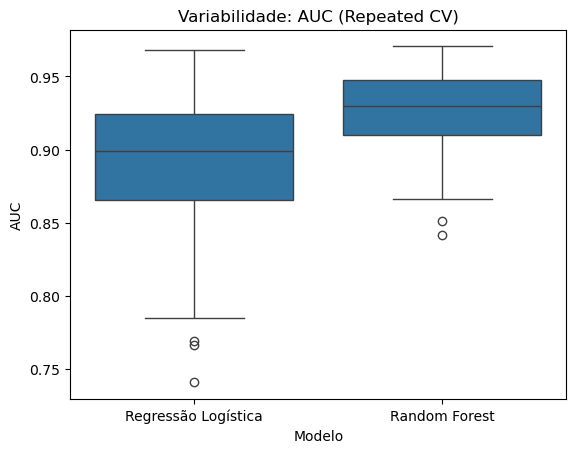

In [32]:
plt.figure()
sns.boxplot(data=df_plot, x="Modelo", y="AUC")
plt.title("Variabilidade: AUC (Repeated CV)")
plt.xlabel("Modelo")
plt.ylabel("AUC")
plt.show()

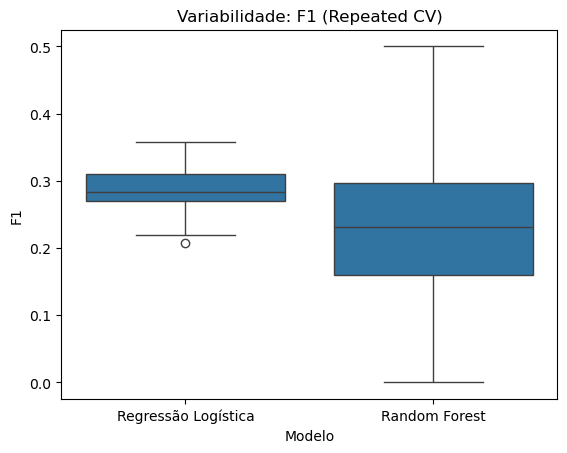

In [33]:
plt.figure()
sns.boxplot(data=df_plot, x="Modelo", y="F1")
plt.title("Variabilidade: F1 (Repeated CV)")
plt.xlabel("Modelo")
plt.ylabel("F1")
plt.show()

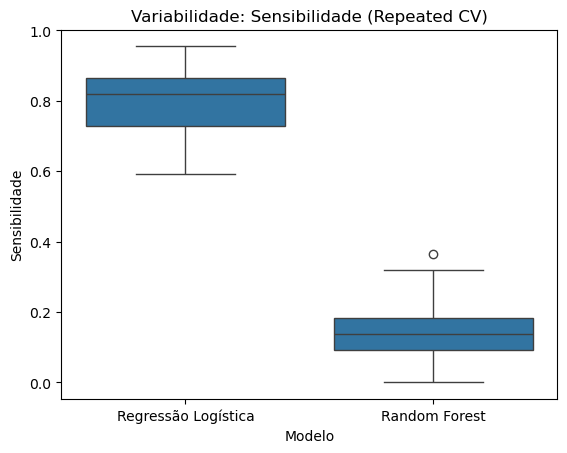

In [34]:
plt.figure()
sns.boxplot(data=df_plot, x="Modelo", y="Sensibilidade")
plt.title("Variabilidade: Sensibilidade (Repeated CV)")
plt.xlabel("Modelo")
plt.ylabel("Sensibilidade")
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_20316\3745522829.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Modelo", y="AUC", palette=palette, ax=axes[0])
C:\Users\andre\AppData\Local\Temp\ipykernel_20316\3745522829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Modelo", y="F1", palette=palette, ax=axes[1])
C:\Users\andre\AppData\Local\Temp\ipykernel_20316\3745522829.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Modelo", y="Sensibilidade", palette=palette, ax=axes[2])


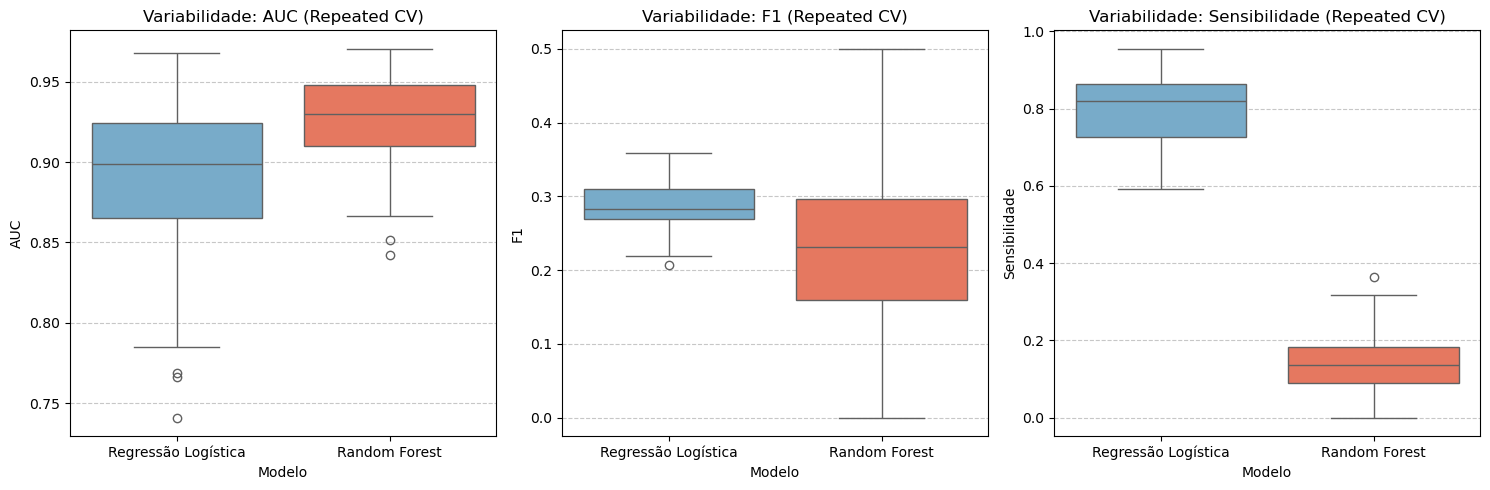

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# paleta personalizada
palette = {
    "Regressão Logística": "#6baed6",  # azul suave
    "Random Forest": "#fb6a4a"         # vermelho suave
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# AUC
sns.boxplot(data=df_plot, x="Modelo", y="AUC", palette=palette, ax=axes[0])
axes[0].set_title("Variabilidade: AUC (Repeated CV)")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("AUC")

# F1
sns.boxplot(data=df_plot, x="Modelo", y="F1", palette=palette, ax=axes[1])
axes[1].set_title("Variabilidade: F1 (Repeated CV)")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("F1")

# Sensibilidade
sns.boxplot(data=df_plot, x="Modelo", y="Sensibilidade", palette=palette, ax=axes[2])
axes[2].set_title("Variabilidade: Sensibilidade (Repeated CV)")
axes[2].set_xlabel("Modelo")
axes[2].set_ylabel("Sensibilidade")

# grid para melhor leitura
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Os modelos são representados com cores distintas para facilitar a comparação visual do desempenho e da variabilidade das métricas.

Os boxplots mostram a variabilidade do desempenho dos modelos ao longo das repetições do Repeated K-Fold. Observa-se que o Random Forest apresenta, em geral, valores medianos superiores de AUC e F1-score, enquanto a regressão logística tende a apresentar maior sensibilidade em alguns cenários.

## Análise de Variabilidade

Os boxplots mostram a variabilidade das métricas ao longo das repetições do Repeated K-Fold.

Observa-se que o Random Forest apresenta valores medianos mais elevados de AUC, enquanto a regressão logística apresenta maior sensibilidade.

A dispersão reduzida indica estabilidade dos modelos, sendo ligeiramente menor no caso do Repeated K-Fold.

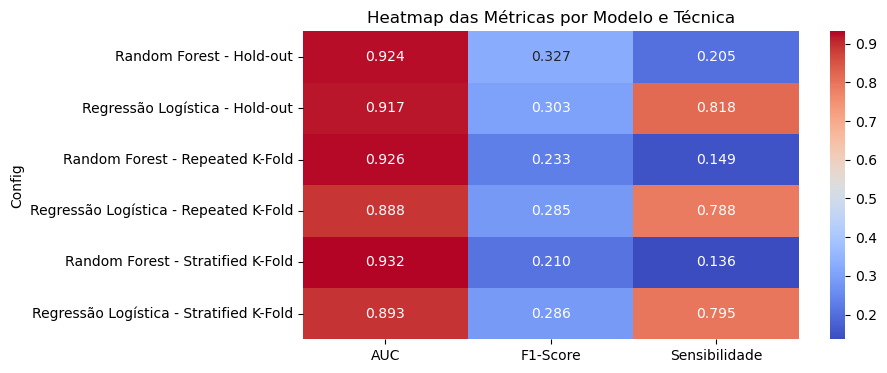

In [37]:
# criar índice combinado
tabela_final["Config"] = tabela_final["Modelo"] + " - " + tabela_final["Técnica"]

df_heat = tabela_final.set_index("Config")[["AUC", "F1-Score", "Sensibilidade"]]

plt.figure(figsize=(8,4))
sns.heatmap(df_heat, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Heatmap das Métricas por Modelo e Técnica")
plt.show()


Para facilitar a interpretação dos resultados, foi utilizada uma representação visual adicional através de um heatmap, permitindo comparar simultaneamente o desempenho dos modelos e das diferentes técnicas de validação para cada métrica considerada.

Esta abordagem permite manter todos os valores numéricos, ao mesmo tempo que evidencia padrões e diferenças de desempenho de forma mais intuitiva.


## Comparação com o Artigo

Os resultados obtidos estão em linha com o estudo de Tougui et al. (2021), que demonstra que a escolha da técnica de validação cruzada pode influenciar significativamente a avaliação do desempenho dos modelos.

Em particular, o uso de Repeated Stratified K-Fold permite obter estimativas mais estáveis e fiáveis, reduzindo a variabilidade associada ao método hold-out.

Adicionalmente, tal como referido no artigo, a escolha inadequada de técnicas de validação pode levar à sobrestimação do desempenho dos modelos. No presente trabalho, apesar dos valores elevados de AUC, métricas como o F1-score e a sensibilidade evidenciam limitações na deteção da classe minoritária.

Estes resultados reforçam a importância da escolha adequada das técnicas de validação, especialmente em contextos com dados desbalanceados.

## Conclusão

Conclui-se que o Random Forest apresenta melhor desempenho global em termos de AUC, enquanto a regressão logística se destaca na deteção da classe minoritária.

A escolha da técnica de validação influencia significativamente os resultados, sendo o Repeated Stratified K-Fold a abordagem mais robusta para estimar o desempenho dos modelos.

Este estudo evidencia a importância de considerar a natureza dos dados e a técnica de validação na avaliação de modelos de machine learning.